In [2]:
import polars as pl
import numpy as np
from pathlib import Path
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

# Copy zip from Drive to local VM and unzip
!cp /content/drive/MyDrive/analyzed_yellow_taxi.zip /content/
!unzip -q /content/analyzed_yellow_taxi.zip

Mounted at /content/drive


In [4]:
"""PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

ANALYZED_PARQUET_PATH = PROJECT_ROOT / "data/processed/analyzed_yellow_taxi.parquet"""

'PROJECT_ROOT = Path.cwd()\nif not (PROJECT_ROOT / "data").exists():\n    PROJECT_ROOT = PROJECT_ROOT.parent\n\nANALYZED_PARQUET_PATH = PROJECT_ROOT / "data/processed/analyzed_yellow_taxi.parquet'

In [5]:
ANALYZED_PARQUET_PATH = "/content/analyzed_yellow_taxi.parquet"

In [6]:
analyzed_lf = pl.scan_parquet(ANALYZED_PARQUET_PATH)
analyzed_lf.head(5).collect()

tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,total_amount,month_name
datetime[μs],datetime[μs],i32,f32,i32,i32,f32,str
2025-03-31 08:25:18,2025-03-31 08:31:33,1,0.92,164,233,13.65,"""March"""
2025-03-31 08:35:17,2025-03-31 08:56:30,1,10.55,229,138,59.59,"""March"""
2025-03-31 08:45:27,2025-03-31 08:59:43,1,2.8,79,162,20.65,"""March"""
2025-03-31 08:12:55,2025-03-31 08:21:41,1,1.5,263,163,19.35,"""March"""
2025-03-31 08:21:32,2025-03-31 08:33:03,1,1.57,224,186,18.0,"""March"""


In [7]:
an_pl_df = analyzed_lf.collect(engine="streaming")

Make the columns binary and ensure the model can properly "understand" time

In [8]:
df_pl = an_pl_df.with_columns([
    (pl.col('passenger_count') >=2).cast(pl.Int8).alias("is_multi"),
    pl.col("tpep_pickup_datetime").cast(pl.Datetime("us"), strict=False),
]).with_columns([
    pl.col("tpep_pickup_datetime").dt.hour().alias("pickup_hour"),
    pl.col("tpep_pickup_datetime").dt.weekday().alias("pickup_dow"),
]).with_columns([
    (pl.col("pickup_dow").is_in([5,6])).cast(pl.Int8).alias("is_weekend"),

    (pl.col("pickup_hour").cast(pl.Float32)
    .map_elements(lambda h: np.sin(2 * np.pi * h/24.0))
    .alias("pickup_hour_sin")),
    (pl.col("pickup_hour").cast(pl.Float32)
    .map_elements(lambda h: np.cos(2 * np.pi * h/24.0))
    .alias("pickup_hour_cos")),
])

In [9]:
feature_cols = [
    "pickup_hour_sin", "pickup_hour_cos",
    "pickup_dow", "is_weekend",
    "PULocationID"
]

numeric_cols = [
    "pickup_hour_sin", "pickup_hour_cos"
]

categorical_cols = [
    "pickup_dow", "is_weekend", "PULocationID"
]

target_col = "is_multi"

In [10]:
df_small = df_pl.select(feature_cols + [target_col])
df_pd = df_small.to_pandas()

X = df_pd[feature_cols]
y = df_pd[target_col]

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression


# Logistic regression (with gradient-based solvers) converges more reliably when inputs are on comparable scales.
numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])
# drop="first" Removes the first category column to prevent multicollinearity (dummy variable trap).
# Otherwise, you create columns that perfectly predict each other (e.g., if is_weekend_0 is false, is_weekend_1 must be true)
categorical_transformer = Pipeline(steps=[("onehot", OneHotEncoder(drop='first', handle_unknown='ignore'))])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)

    ]
)

log_reg = LogisticRegression(
    l1_ratio=0,
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", log_reg)
])

clf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['pickup_hour_sin',
                                                   'pickup_hour_cos']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['pickup_dow', 'is_weekend',
                                                   'PULocationID'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', l1_ratio=0,
                                    max_iter=1000))])

ROC AUC:  0.613093239523473

PR AUC (for multi-passenger):  0.26733285391971606

Classification report:
               precision    recall  f1-score   support

           0       0.85      0.59      0.69   5665361
           1       0.26      0.57      0.35   1399285

    accuracy                           0.59   7064646
   macro avg       0.55      0.58      0.52   7064646
weighted avg       0.73      0.59      0.63   7064646



<Axes: >

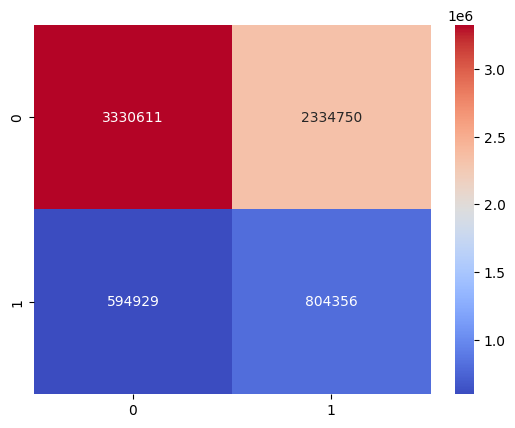

In [13]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

y_val_pred = clf.predict(X_val)
y_val_proba = clf.predict_proba(X_val)[:, 1]

print("ROC AUC: ",roc_auc_score(y_val, y_val_proba))
print("\nPR AUC (for multi-passenger): ",average_precision_score(y_val, y_val_proba))

print("\nClassification report:\n",classification_report(y_val, y_val_pred))

cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, cmap="coolwarm", fmt='d')

the behavior at threshold 0.5 is:

Very aggressive in calling trips multi → high recall for multi, but massive number of false multi alarms.

This is consistent with class_weight='balanced' pushing the model to care about the minority, plus the skewed data and the particular decision boundary.

Given singles are the majority, 0.57 accuracy is actually worse than a dumb baseline that predicts “single” for everyone:

That baseline would get accuracy ≈ 80% (since ~80% are singles).

So in terms of hard labels at threshold 0.5, your classifier is doing worse than always predicting class 0, because it is trying to capture the minority class aggressively.

tuning threshold, think about what to care about via precision vs recall for single vs multi.... maybe the baseline

So we're gonna first tune that threshold=0.5 to prioritise high precision for multi whilst keeping recall tolerable...

In [14]:
from sklearn.metrics import precision_score, recall_score
import pandas as pd

In [15]:
thresholds = np.linspace(0.0, 1.0, 101)

results = []

# y_val_proba is a 1D array of predicted probabilities for the positive class
# confident enough (probability ≥ t) that the trip is multi-passenger.

for t in thresholds:
    y_pred_t = (y_val_proba >= t).astype(int)
 # If the model never predicts class 1 at this threshold, skip (precision undefined)
    if y_pred_t.sum() == 0:
        continue

    prec = precision_score(y_val, y_pred_t, pos_label=1)
    rec = recall_score(y_val, y_pred_t, pos_label=1)
    results.append((t, prec, rec))

In [16]:
target_precision = 0.4

In [17]:
res_df = pd.DataFrame(results, columns=["threshold", "precision", "recall"])

good = res_df[res_df["precision"] >= target_precision]

if good.empty:
    print("No threshold achieves the desired precision. Try lowering target_precision.")
else:
    best = good.sort_values("recall", ascending=False).iloc[0]
    print(best)
    best_threshold = best["threshold"]
    print("Chosen threshold:", best_threshold)

No threshold achieves the desired precision. Try lowering target_precision.


Definitely not worth it!... i'll need to try another model maybe since i doubt i could make the features any better than they are now. But i think let's first tune Logisitc Regression some more... like via class_weights and regularization

In [18]:
"""from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

pipe = Pipeline([
    ("scale", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("clf", LogisticRegression(
        solver="saga",
        class_weight="balanced",
        max_iter=5000
    ))
])

pipe.fit(X_train, y_train)"""

'from imblearn.pipeline import Pipeline\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.linear_model import LogisticRegression\nfrom imblearn.over_sampling import SMOTE\n\npipe = Pipeline([\n    ("scale", StandardScaler()),\n    ("smote", SMOTE(random_state=42)),\n    ("clf", LogisticRegression(\n        solver="saga",\n        class_weight="balanced",\n        max_iter=5000\n    ))\n])\n\npipe.fit(X_train, y_train)'

Train the configured logistic regression pipeline directly (no cross-validation search).

Run a plain training pass with the configured pipeline.

In [19]:
"""print("Plain training complete. Model hyperparameters:")
print(pipe.named_steps["clf"].get_params())"""

'print("Plain training complete. Model hyperparameters:")\nprint(pipe.named_steps["clf"].get_params())'

Save the trained model, parameters, and validation metrics for reuse.

In [20]:
import joblib
import json
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
)

"""best_model = pipe
best_params = {
    "smote": pipe.named_steps["smote"].get_params(),
    "logistic_regression": pipe.named_steps["clf"].get_params(),
}

artifact_dir = PROJECT_ROOT / "data/processed/model_artifacts/logreg_smote"
artifact_dir.mkdir(parents=True, exist_ok=True)

best_val_pred = best_model.predict(X_val)
best_val_proba = best_model.predict_proba(X_val)[:, 1]

metrics = {
    "accuracy": float(accuracy_score(y_val, best_val_pred)),
    "precision": float(precision_score(y_val, best_val_pred, zero_division=0)),
    "recall": float(recall_score(y_val, best_val_pred, zero_division=0)),
    "f1": float(f1_score(y_val, best_val_pred, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_val, best_val_proba)),
    "average_precision": float(average_precision_score(y_val, best_val_proba)),
    "classification_report": classification_report(y_val, best_val_pred, output_dict=True, zero_division=0),
}

params_path = artifact_dir / "logreg_smote_best_params.json"
metrics_path = artifact_dir / "logreg_smote_metrics.json"
model_path = artifact_dir / "logreg_smote_best_model.joblib"

with open(params_path, "w") as f:
    json.dump(best_params, f, indent=2, default=float)

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2, default=float)

joblib.dump(best_model, model_path)

print(f"Saved model artifacts to: {artifact_dir}")
print(f"- Model: {model_path.name}")
print(f"- Params: {params_path.name}")
print(f"- Metrics: {metrics_path.name}")"""

'best_model = pipe\nbest_params = {\n    "smote": pipe.named_steps["smote"].get_params(),\n    "logistic_regression": pipe.named_steps["clf"].get_params(),\n}\n\nartifact_dir = PROJECT_ROOT / "data/processed/model_artifacts/logreg_smote"\nartifact_dir.mkdir(parents=True, exist_ok=True)\n\nbest_val_pred = best_model.predict(X_val)\nbest_val_proba = best_model.predict_proba(X_val)[:, 1]\n\nmetrics = {\n    "accuracy": float(accuracy_score(y_val, best_val_pred)),\n    "precision": float(precision_score(y_val, best_val_pred, zero_division=0)),\n    "recall": float(recall_score(y_val, best_val_pred, zero_division=0)),\n    "f1": float(f1_score(y_val, best_val_pred, zero_division=0)),\n    "roc_auc": float(roc_auc_score(y_val, best_val_proba)),\n    "average_precision": float(average_precision_score(y_val, best_val_proba)),\n    "classification_report": classification_report(y_val, best_val_pred, output_dict=True, zero_division=0),\n}\n\nparams_path = artifact_dir / "logreg_smote_best_params

Currently facing a challenge of compute... even Colab was of no help to me! I may need to use the machines at the university. For now i will test with another model since that's what i would have done either way! For now let's try out GBTs...

In [23]:
import lightgbm as lgb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

In [24]:
train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

In [25]:
params = {
"objective":"binary",
"metric":["auc","binary_logloss"],
"boosting_type":"gbdt",
"learning_rate":0.05,
"num_leaves":31,
"max_depth":-1,
"feature_fraction":0.8,
"bagging_fraction":0.8,
"bagging_freq":5,
"lambda_l1":0.1,
"lambda_l2":0.2,
"min_data_in_leaf":20,
"verbose":-1
}

In [26]:
lgb_model = lgb.train(
    params,
    train_data,
    num_boost_round=100,
    valid_sets=[train_data, valid_data],
    valid_names=["train", "valid"],
    callbacks=[lgb.early_stopping(50)]
)

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[100]	train's auc: 0.620574	train's binary_logloss: 0.483247	valid's auc: 0.620778	valid's binary_logloss: 0.483217


In [27]:
lgb_pred_proba = lgb_model.predict(X_val, num_iteration=lgb_model.best_iteration)
lgb_pred_proba = np.asarray(lgb_pred_proba)
lgb_pred = (lgb_pred_proba > 0.5).astype(int)

In [28]:
lgb_pred_proba = np.asarray(lgb_pred_proba, dtype=float).ravel()

print("LightGBM Results:")
print("ROC AUC:", roc_auc_score(y_val, lgb_pred_proba))
print("PR AUC:", average_precision_score(y_val, lgb_pred_proba))
print("\nClassification Report:")
print(classification_report(y_val, lgb_pred))

LightGBM Results:
ROC AUC: 0.6207779814890096
PR AUC: 0.27495816688528507

Classification Report:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.80      1.00      0.89   5665361
           1       0.00      0.00      0.00   1399285

    accuracy                           0.80   7064646
   macro avg       0.40      0.50      0.45   7064646
weighted avg       0.64      0.80      0.71   7064646



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [29]:
lgb_metrics = {
    "accuracy": float(accuracy_score(y_val, lgb_pred)),
    "precision": float(precision_score(y_val, lgb_pred, zero_division=0)),
    "recall": float(recall_score(y_val, lgb_pred, zero_division=0)),
    "f1": float(f1_score(y_val, lgb_pred, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_val, lgb_pred_proba)),
    "average_precision": float(average_precision_score(y_val, lgb_pred_proba)),
    "classification_report": classification_report(y_val, lgb_pred, output_dict=True, zero_division=0),
}

"""lgb_artifact_dir = PROJECT_ROOT / "data/processed/model_artifacts/lightgbm"
lgb_artifact_dir.mkdir(parents=True, exist_ok=True)

lgb_params_path = lgb_artifact_dir / "lightgbm_params.json"
lgb_metrics_path = lgb_artifact_dir / "lightgbm_metrics.json"
lgb_model_path = lgb_artifact_dir / "lightgbm_model.txt"

with open(lgb_params_path, "w") as f:
    json.dump(params, f, indent=2, default=float)

with open(lgb_metrics_path, "w") as f:
    json.dump(lgb_metrics, f, indent=2, default=float)

lgb_model.save_model(str(lgb_model_path))

print(f"Saved LightGBM artifacts to: {lgb_artifact_dir}")
print(f"- Model: {lgb_model_path.name}")
print(f"- Params: {lgb_params_path.name}")
print(f"- Metrics: {lgb_metrics_path.name}")"""

'lgb_artifact_dir = PROJECT_ROOT / "data/processed/model_artifacts/lightgbm"\nlgb_artifact_dir.mkdir(parents=True, exist_ok=True)\n\nlgb_params_path = lgb_artifact_dir / "lightgbm_params.json"\nlgb_metrics_path = lgb_artifact_dir / "lightgbm_metrics.json"\nlgb_model_path = lgb_artifact_dir / "lightgbm_model.txt"\n\nwith open(lgb_params_path, "w") as f:\n    json.dump(params, f, indent=2, default=float)\n\nwith open(lgb_metrics_path, "w") as f:\n    json.dump(lgb_metrics, f, indent=2, default=float)\n\nlgb_model.save_model(str(lgb_model_path))\n\nprint(f"Saved LightGBM artifacts to: {lgb_artifact_dir}")\nprint(f"- Model: {lgb_model_path.name}")\nprint(f"- Params: {lgb_params_path.name}")\nprint(f"- Metrics: {lgb_metrics_path.name}")'

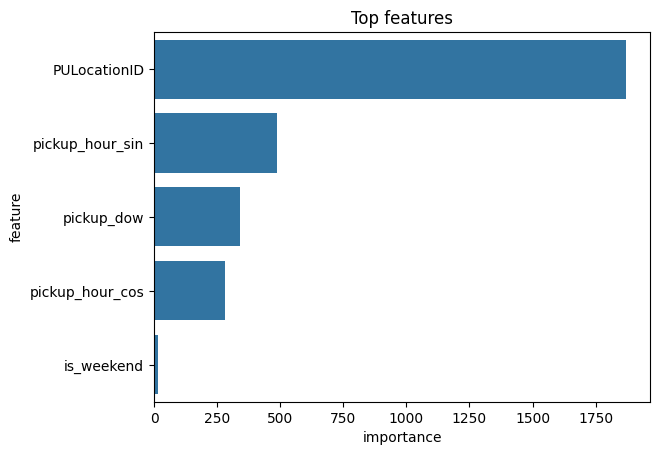

In [30]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": lgb_model.feature_importance()
}).sort_values(by="importance", ascending=False)

sns.barplot(x="importance", y="feature", data=importance)
plt.title("Top features")
plt.show()

In [31]:
from lightgbm import Dataset

train_set = Dataset(X_train, label=y_train)
val_set = Dataset(X_val, label=y_val)

plain_lgb_model = lgb.train(
    params,
    train_set,
    num_boost_round=100,
    valid_sets=[val_set],
    callbacks=[
        lgb.early_stopping(30),
        lgb.log_evaluation(0)
    ]
)

plain_preds = plain_lgb_model.predict(X_val)
plain_preds = np.asarray(plain_preds).ravel()
print("Validation ROC AUC:", roc_auc_score(y_val, plain_preds))

Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's auc: 0.620778	valid_0's binary_logloss: 0.483217
Validation ROC AUC: 0.6207779814890096


XGBoost Implemenation

In [32]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 1.2 MB/s eta 0:00:00


In [33]:
import xgboost as xgb

In [34]:
# Create copies to avoid modifying original splits
X_train_xgb = X_train.copy()
X_val_xgb = X_val.copy()

X_train_xgb["PULocationID"] = X_train_xgb["PULocationID"].astype('category')
X_val_xgb["PULocationID"] = X_val_xgb["PULocationID"].astype('category')

In [35]:
xgb_train = xgb.DMatrix(X_train_xgb, y_train, enable_categorical=True)
xgb_val = xgb.DMatrix(X_val_xgb, y_val, enable_categorical=True)

In [36]:
xgb_params = {
    'objective': 'binary:logistic',
    'max_depth': 3,
    'learning_rate': 0.1,
}
xgb_rounds = 50
xgb_model = xgb.train(params=xgb_params, dtrain=xgb_train, num_boost_round=xgb_rounds, evals=[(xgb_val, 'val')])

[0]	val-logloss:0.49577
[1]	val-logloss:0.49414
[2]	val-logloss:0.49280
[3]	val-logloss:0.49163
[4]	val-logloss:0.49067
[5]	val-logloss:0.48979
[6]	val-logloss:0.48907
[7]	val-logloss:0.48838
[8]	val-logloss:0.48781
[9]	val-logloss:0.48733
[10]	val-logloss:0.48689
[11]	val-logloss:0.48646
[12]	val-logloss:0.48611
[13]	val-logloss:0.48580
[14]	val-logloss:0.48546
[15]	val-logloss:0.48522
[16]	val-logloss:0.48502
[17]	val-logloss:0.48482
[18]	val-logloss:0.48465
[19]	val-logloss:0.48444
[20]	val-logloss:0.48430
[21]	val-logloss:0.48416
[22]	val-logloss:0.48405
[23]	val-logloss:0.48394
[24]	val-logloss:0.48383
[25]	val-logloss:0.48373
[26]	val-logloss:0.48364
[27]	val-logloss:0.48356
[28]	val-logloss:0.48340
[29]	val-logloss:0.48329
[30]	val-logloss:0.48317
[31]	val-logloss:0.48311
[32]	val-logloss:0.48305
[33]	val-logloss:0.48300
[34]	val-logloss:0.48296
[35]	val-logloss:0.48292
[36]	val-logloss:0.48284
[37]	val-logloss:0.48275
[38]	val-logloss:0.48268
[39]	val-logloss:0.48265
[40]	val-l

In [37]:
y_pred_proba_xgb = np.asarray(xgb_model.predict(xgb_val))
y_pred_xgb = (y_pred_proba_xgb > 0.5).astype(int)

print("XGBoost Results:")
print("ROC AUC:", roc_auc_score(y_val, y_pred_proba_xgb))
print("PR AUC:", average_precision_score(y_val, y_pred_proba_xgb))
print("\nClassification Report:")
print(classification_report(y_val, y_pred_xgb))

xgb_metrics = {
    "accuracy": float(accuracy_score(y_val, y_pred_xgb)),
    "precision": float(precision_score(y_val, y_pred_xgb, zero_division=0)),
    "recall": float(recall_score(y_val, y_pred_xgb, zero_division=0)),
    "f1": float(f1_score(y_val, y_pred_xgb, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_val, y_pred_proba_xgb)),
    "average_precision": float(average_precision_score(y_val, y_pred_proba_xgb)),
    "classification_report": classification_report(y_val, y_pred_xgb, output_dict=True, zero_division=0),
}

"""xgb_artifact_dir = PROJECT_ROOT / "data/processed/model_artifacts/xgboost"
xgb_artifact_dir.mkdir(parents=True, exist_ok=True)

xgb_params_path = xgb_artifact_dir / "xgboost_params.json"
xgb_metrics_path = xgb_artifact_dir / "xgboost_metrics.json"
xgb_model_path = xgb_artifact_dir / "xgboost_model.json"

with open(xgb_params_path, "w") as f:
    json.dump({"params": xgb_params, "num_boost_round": xgb_rounds}, f, indent=2, default=float)

with open(xgb_metrics_path, "w") as f:
    json.dump(xgb_metrics, f, indent=2, default=float)

xgb_model.save_model(str(xgb_model_path))

print(f"Saved XGBoost artifacts to: {xgb_artifact_dir}")
print(f"- Model: {xgb_model_path.name}")
print(f"- Params: {xgb_params_path.name}")
print(f"- Metrics: {xgb_metrics_path.name}")"""

XGBoost Results:
ROC AUC: 0.622198219620491
PR AUC: 0.2753602757023999

Classification Report:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.80      1.00      0.89   5665361
           1       0.00      0.00      0.00   1399285

    accuracy                           0.80   7064646
   macro avg       0.40      0.50      0.45   7064646
weighted avg       0.64      0.80      0.71   7064646



'xgb_artifact_dir = PROJECT_ROOT / "data/processed/model_artifacts/xgboost"\nxgb_artifact_dir.mkdir(parents=True, exist_ok=True)\n\nxgb_params_path = xgb_artifact_dir / "xgboost_params.json"\nxgb_metrics_path = xgb_artifact_dir / "xgboost_metrics.json"\nxgb_model_path = xgb_artifact_dir / "xgboost_model.json"\n\nwith open(xgb_params_path, "w") as f:\n    json.dump({"params": xgb_params, "num_boost_round": xgb_rounds}, f, indent=2, default=float)\n\nwith open(xgb_metrics_path, "w") as f:\n    json.dump(xgb_metrics, f, indent=2, default=float)\n\nxgb_model.save_model(str(xgb_model_path))\n\nprint(f"Saved XGBoost artifacts to: {xgb_artifact_dir}")\nprint(f"- Model: {xgb_model_path.name}")\nprint(f"- Params: {xgb_params_path.name}")\nprint(f"- Metrics: {xgb_metrics_path.name}")'

CatBoost

In [38]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 4.4 MB/s eta 0:00:00


In [39]:
from catboost import CatBoostClassifier

In [40]:
cat_features = ["PULocationID"]

In [41]:
cat_model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    loss_function='Logloss',
    verbose=100  # Prints output every 100 iterations
)


In [42]:
cat_model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_val, y_val), # Evaluate on validation set while training
    early_stopping_rounds=50   # Stop if validation score stops improving
)

0:	learn: 0.6574033	test: 0.6574129	best: 0.6574129 (0)	total: 1.95s	remaining: 3m 12s
99:	learn: 0.4826020	test: 0.4825764	best: 0.4825764 (99)	total: 2m 43s	remaining: 0us

bestTest = 0.4825763942
bestIteration = 99



CatBoostClassifier(depth=6, iterations=100, learning_rate=0.1, loss_function='Logloss', verbose=100)

In [43]:
# Get class predictions and probability predictions
preds_class_cat = np.asarray(cat_model.predict(X_val)).astype(int).ravel()
preds_proba_cat = np.asarray(cat_model.predict_proba(X_val)[:, 1])

print("CatBoost Results:")
print("ROC AUC:", roc_auc_score(y_val, preds_proba_cat))
print("PR AUC:", average_precision_score(y_val, preds_proba_cat))
print("\nClassification Report:")
print(classification_report(y_val, preds_class_cat))

cat_metrics = {
    "accuracy": float(accuracy_score(y_val, preds_class_cat)),
    "precision": float(precision_score(y_val, preds_class_cat, zero_division=0)),
    "recall": float(recall_score(y_val, preds_class_cat, zero_division=0)),
    "f1": float(f1_score(y_val, preds_class_cat, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_val, preds_proba_cat)),
    "average_precision": float(average_precision_score(y_val, preds_proba_cat)),
    "classification_report": classification_report(y_val, preds_class_cat, output_dict=True, zero_division=0),
}

"""cat_artifact_dir = PROJECT_ROOT / "data/processed/model_artifacts/catboost"
cat_artifact_dir.mkdir(parents=True, exist_ok=True)

cat_params_path = cat_artifact_dir / "catboost_params.json"
cat_metrics_path = cat_artifact_dir / "catboost_metrics.json"
cat_model_path = cat_artifact_dir / "catboost_model.cbm"

with open(cat_params_path, "w") as f:
    json.dump(cat_model.get_params(), f, indent=2, default=float)

with open(cat_metrics_path, "w") as f:
    json.dump(cat_metrics, f, indent=2, default=float)

cat_model.save_model(str(cat_model_path))

print(f"Saved CatBoost artifacts to: {cat_artifact_dir}")
print(f"- Model: {cat_model_path.name}")
print(f"- Params: {cat_params_path.name}")
print(f"- Metrics: {cat_metrics_path.name}")"""

CatBoost Results:
ROC AUC: 0.620002771251079
PR AUC: 0.27402611205445093

Classification Report:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.80      1.00      0.89   5665361
           1       0.00      0.00      0.00   1399285

    accuracy                           0.80   7064646
   macro avg       0.40      0.50      0.45   7064646
weighted avg       0.64      0.80      0.71   7064646



'cat_artifact_dir = PROJECT_ROOT / "data/processed/model_artifacts/catboost"\ncat_artifact_dir.mkdir(parents=True, exist_ok=True)\n\ncat_params_path = cat_artifact_dir / "catboost_params.json"\ncat_metrics_path = cat_artifact_dir / "catboost_metrics.json"\ncat_model_path = cat_artifact_dir / "catboost_model.cbm"\n\nwith open(cat_params_path, "w") as f:\n    json.dump(cat_model.get_params(), f, indent=2, default=float)\n\nwith open(cat_metrics_path, "w") as f:\n    json.dump(cat_metrics, f, indent=2, default=float)\n\ncat_model.save_model(str(cat_model_path))\n\nprint(f"Saved CatBoost artifacts to: {cat_artifact_dir}")\nprint(f"- Model: {cat_model_path.name}")\nprint(f"- Params: {cat_params_path.name}")\nprint(f"- Metrics: {cat_metrics_path.name}")'

Due to severe compute constraints, the models are clearly subpar and hence we will stick with logisitc regression